In [52]:
# 9. CIVIL / CONSTRUCTION MATERIAL ANALYTICS
# PS
# Construction material strength depends on complex mixtures of components such as cement, water, and aggregates, with non-linear relationships affecting durability.

# BO 
# Predict material strength quality - prediction done with test data
# Optimize mix composition 
# Improve construction reliability 
# Reduce material failure risk 

# DI
# Material composition data including cement, water, aggregates, additives, and curing conditions.

# ML Objective
# Use SVM regression/classification to model material strength behavior and analyze non-linear feature relationships.

<bound method NDFrame.head of           cement     fly_ash       water  superplasticizer  coarse_aggregate  \
0     287.270059  112.092246  209.499747         31.907228        798.912041   
1     575.357153   99.873629  127.676799         22.964623        594.817775   
2     465.996971   52.846174  151.995954         48.224926        626.359225   
3     399.329242  182.180001  199.492096         10.948923        680.671128   
4     178.009320  142.987248  172.313402         29.392821        703.653334   
...          ...         ...         ...               ...               ...   
9995  528.827994  263.111589  242.841318         37.701695       1122.445201   
9996  548.754418   14.044187  212.173632         38.226347        726.193574   
9997  573.353958   91.109541  102.918379         13.478472       1248.995085   
9998  298.743996  132.996002  160.150726         21.715989       1021.010912   
9999  208.570202   51.679444  138.609697         24.371185       1361.706710   

      fin

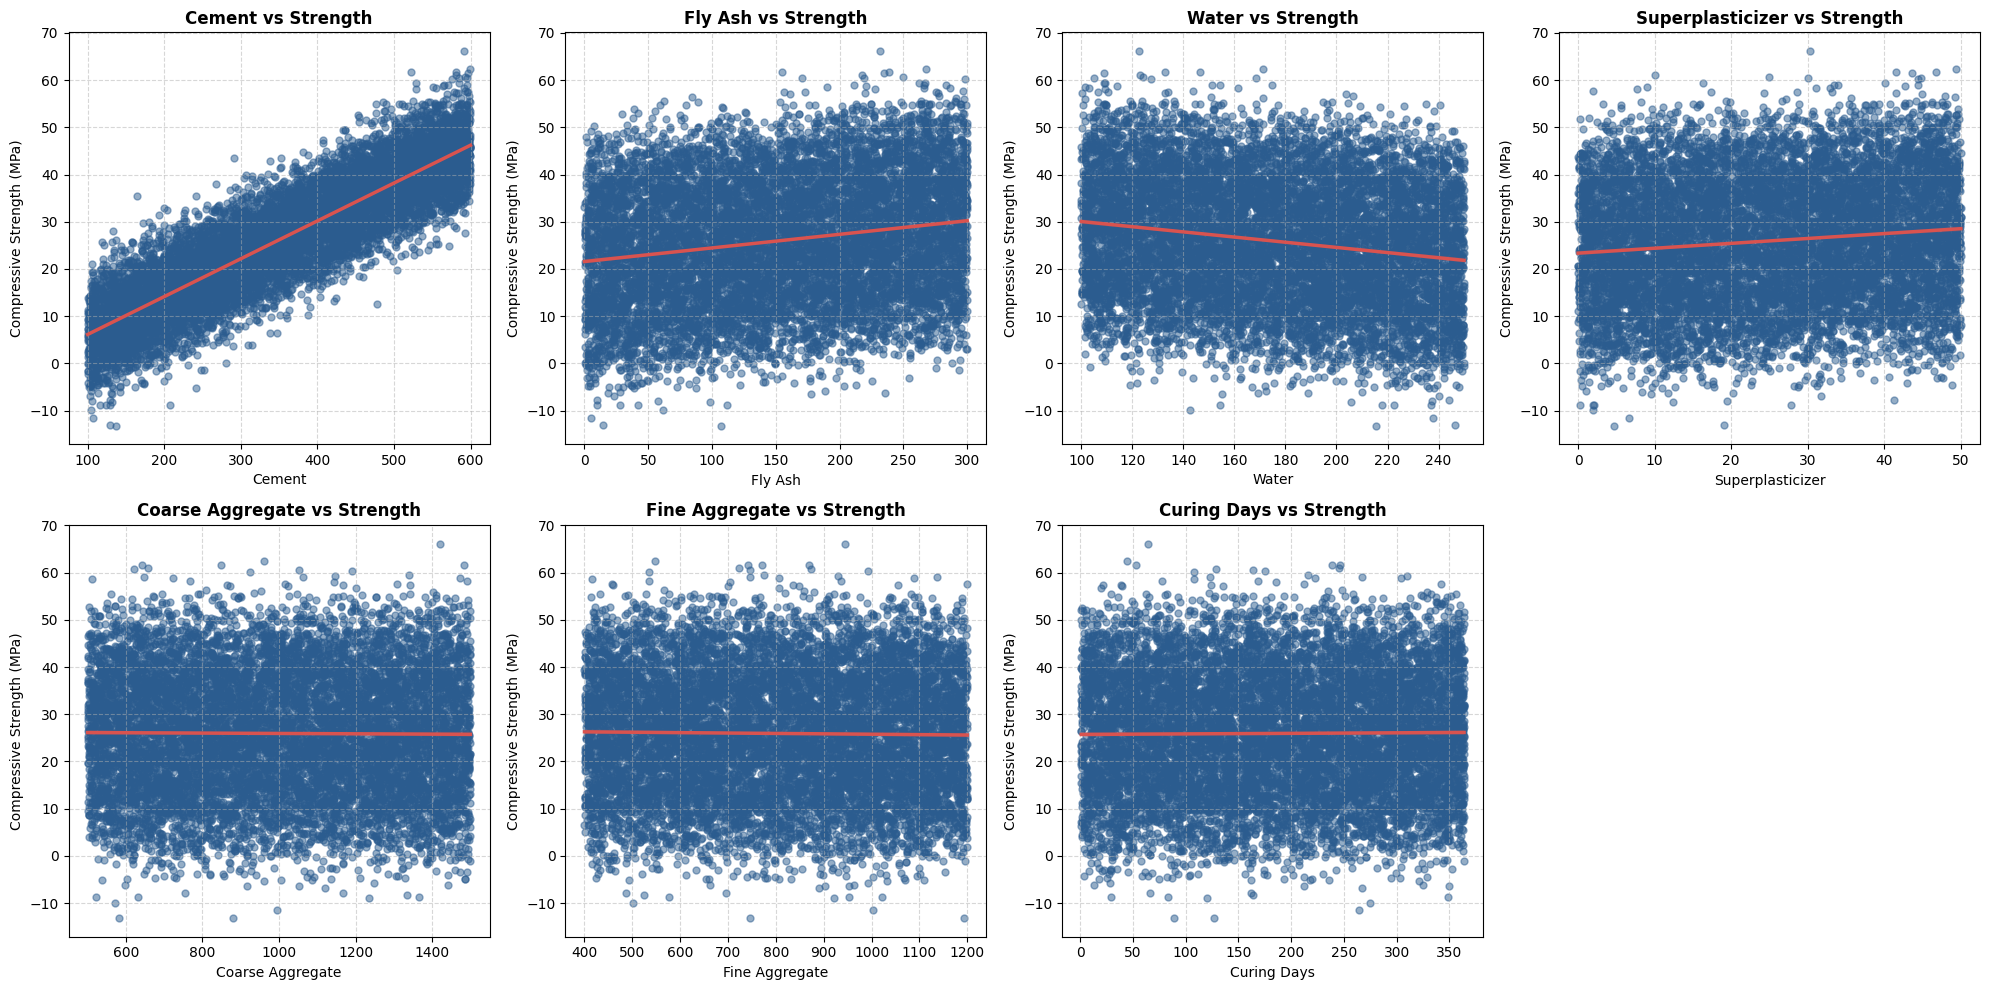

In [1]:
import pandas as pd
# import matplotlib.subplots as plots  
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Data Understanding
# Understand the business problem 
# Explore dataset structure 
# Identify numerical and categorical features  - all are numerical
# Understand the target variable behavior - strength depends on all other params


df = pd.read_csv('construction_dataset.csv')
print(df.head)
print(df.shape)


# Define features and target variable
features = [
    'cement', 'fly_ash', 'water', 'superplasticizer', 
    'coarse_aggregate', 'fine_aggregate', 'curing_days'
]
target = 'compressive_strength'

# 2. Create a grid layout (2 rows x 4 columns to fit all 7 features cleanly)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy looping

# 3. Loop through each variable and plot it against strength
for i, col in enumerate(features):
    sns.regplot(
        data=df, 
        x=col, 
        y=target, 
        ax=axes[i], 
        scatter_kws={'alpha': 0.5, 'color': '#2b5c8f', 's': 25},
        line_kws={'color': '#d9534f', 'lw': 2.5}
    )
    
    # Clean up formatting and labels
    axes[i].set_title(f"{col.replace('_', ' ').title()} vs Strength", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel('Compressive Strength (MPa)', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 4. Hide the 8th subplot grid space since we only have 7 features
axes[-1].axis('off')

# 5. Save the final visualization grid
plt.tight_layout()


False
Column 'cement': 0 outliers (0.00%)
Column 'fly_ash': 0 outliers (0.00%)
Column 'water': 0 outliers (0.00%)
Column 'superplasticizer': 0 outliers (0.00%)
Column 'coarse_aggregate': 0 outliers (0.00%)
Column 'fine_aggregate': 0 outliers (0.00%)
Column 'curing_days': 0 outliers (0.00%)
Column 'compressive_strength': 1 outliers (0.01%)
  --> Removing 1 outliers from 'compressive_strength'


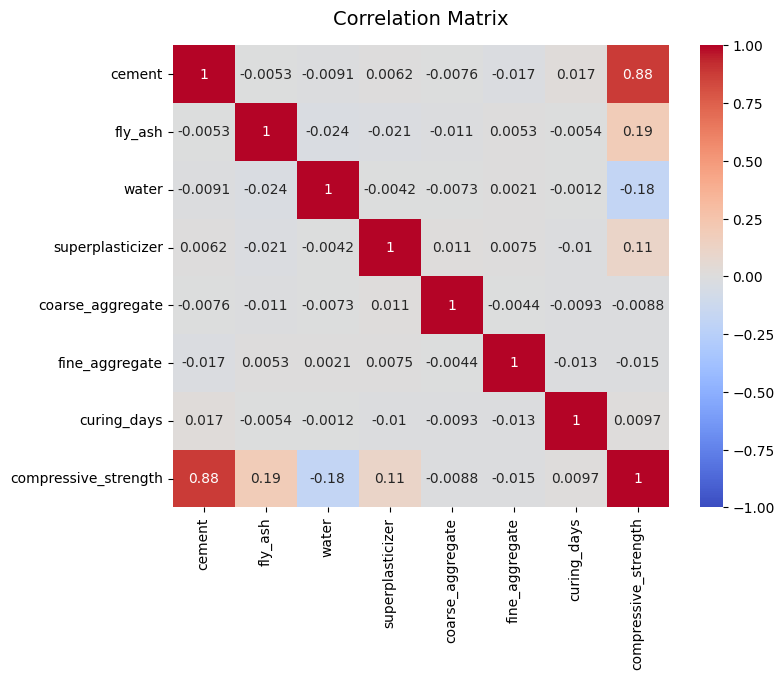

In [2]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy import stats


# 2. Exploratory Data Analysis (EDA)
# Analyze feature distributions 
# Detect missing values 
print(df.isna().values.any()) #false here indicates no null values

# Identify outliers - doing with Z score (removes data apart from threshold standard deviations), also confirming that outlier % is not more than 2
def clean_outliers(df, threshold, limit_pct):
    # Select only numeric columns to avoid errors with strings
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df_clean = df.copy()
    
    for col in numeric_cols:
        # Calculate absolute Z-scores for the column
        z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
        
        # Identify outlier indices
        outlier_mask = z_scores > threshold
        outlier_count = outlier_mask.sum()
        outlier_pct = (outlier_count / len(df)) * 100
        
        print(f"Column '{col}': {outlier_count} outliers ({outlier_pct:.2f}%)")
        
        # Remove if the count is less than 2% of the total rows
        if 0 < outlier_pct < limit_pct:
            print(f"  --> Removing {outlier_count} outliers from '{col}'")
            # Filter the dataframe to keep only non-outliers for this specific column
            df_clean = df_clean[~outlier_mask]
        elif outlier_pct >= limit_pct:
            print(f"  --> Outliers >= {limit_pct}%, keeping column as-is.")
            
    return df_clean


df_clean = clean_outliers(df, 3, 2.0)


# Study feature correlations 
correlation_matrix = df_clean.corr()
# print(correlation_matrix)

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
heatmap.set_title('Correlation Matrix', fontsize=14, pad=15)
plt.show()

# Visualize inventory and sales behavior (different columns visualization done above)


In [3]:
from sklearn.model_selection import train_test_split

# 3. Data Preprocessing
# Encode categorical variables 
df_clean['strength_category'] = pd.qcut(df['compressive_strength'], q=2, labels=[0, 1]).astype(int)
X = df_clean.drop(columns=['compressive_strength', 'strength_category'], axis=1)
# Scale numerical features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

y = df_clean['strength_category']
print(y.head())

# Handle missing values - no missing values in dataset
# Split train and test datasets 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Note: Feature scaling is highly important while working with SVM models. - done with StandardScalaer above

[[-0.41576954 -0.4523691   0.80178203  0.48251059 -0.68420826  1.19343464
   1.31991018]
 [ 1.58769662 -0.59316145 -1.10050749 -0.13637076 -1.3897992  -0.02985987
  -0.55700994]
 [ 0.82716472 -1.13504817 -0.53511508  1.61179205 -1.28075468 -1.06702379
   1.17771926]
 [ 0.36353223  0.35523625  0.56911564 -0.96792846 -1.09298857  0.8098721
   0.13498586]
 [-1.17560987 -0.09637297 -0.06275777  0.30849867 -1.01353491 -0.29288278
   0.22030041]]
0    0
1    1
2    1
3    0
4    0
Name: strength_category, dtype: int64



--- Model Accuracy --- for c  0.01
Accuracy: 88.95%

--- Classification Report --- for c 0.01
              precision    recall  f1-score   support

         Low       0.90      0.88      0.89       999
        High       0.88      0.90      0.89      1001

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

ROC-AUC Score:     0.9626


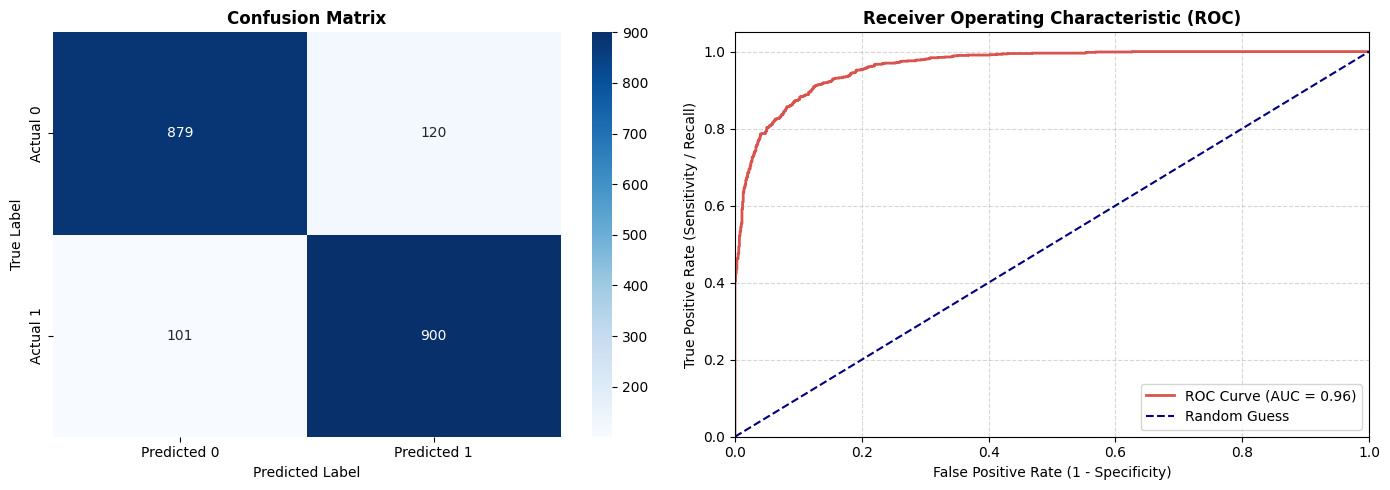


--- Model Accuracy --- for c  0.1
Accuracy: 89.00%

--- Classification Report --- for c 0.1
              precision    recall  f1-score   support

         Low       0.90      0.88      0.89       999
        High       0.88      0.90      0.89      1001

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

ROC-AUC Score:     0.9626


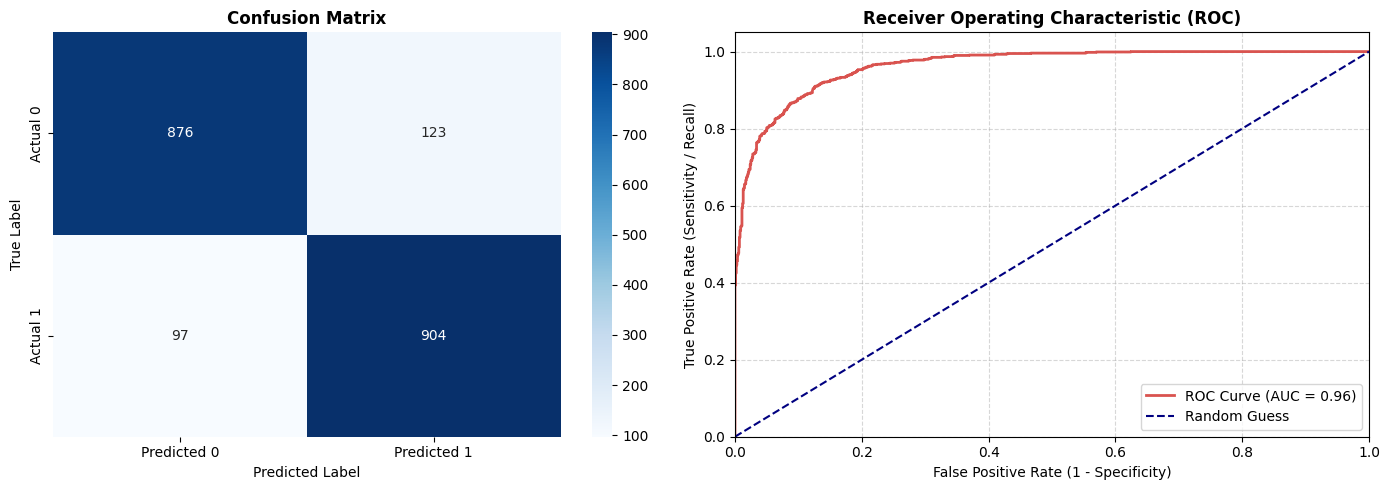


--- Model Accuracy --- for c  1
Accuracy: 88.90%

--- Classification Report --- for c 1
              precision    recall  f1-score   support

         Low       0.90      0.88      0.89       999
        High       0.88      0.90      0.89      1001

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

ROC-AUC Score:     0.9627


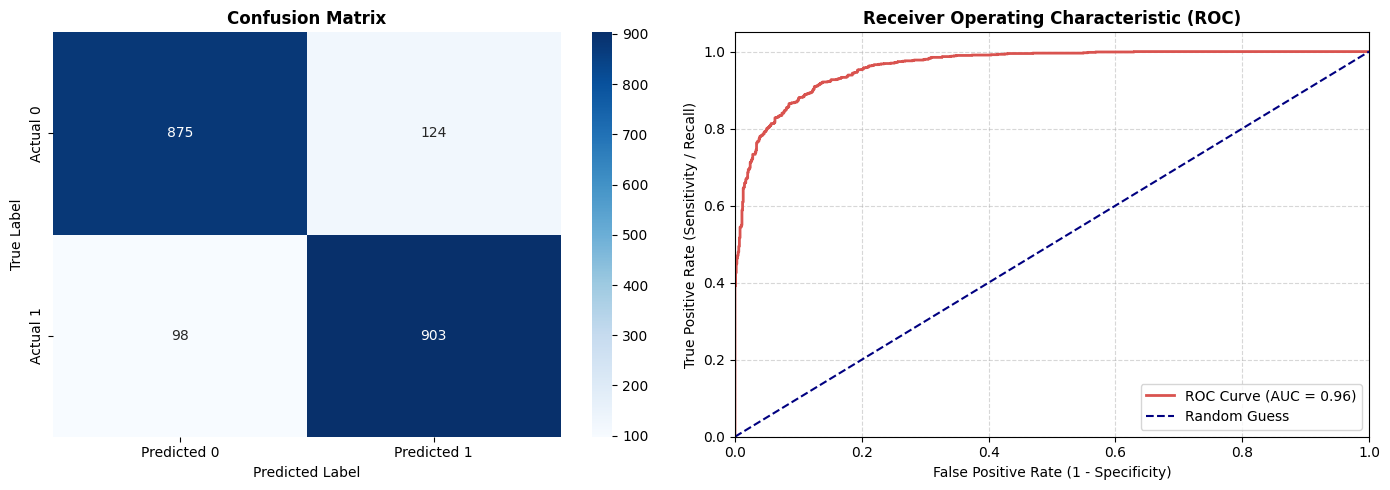


--- Model Accuracy --- for c  10
Accuracy: 88.95%

--- Classification Report --- for c 10
              precision    recall  f1-score   support

         Low       0.90      0.88      0.89       999
        High       0.88      0.90      0.89      1001

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

ROC-AUC Score:     0.9627


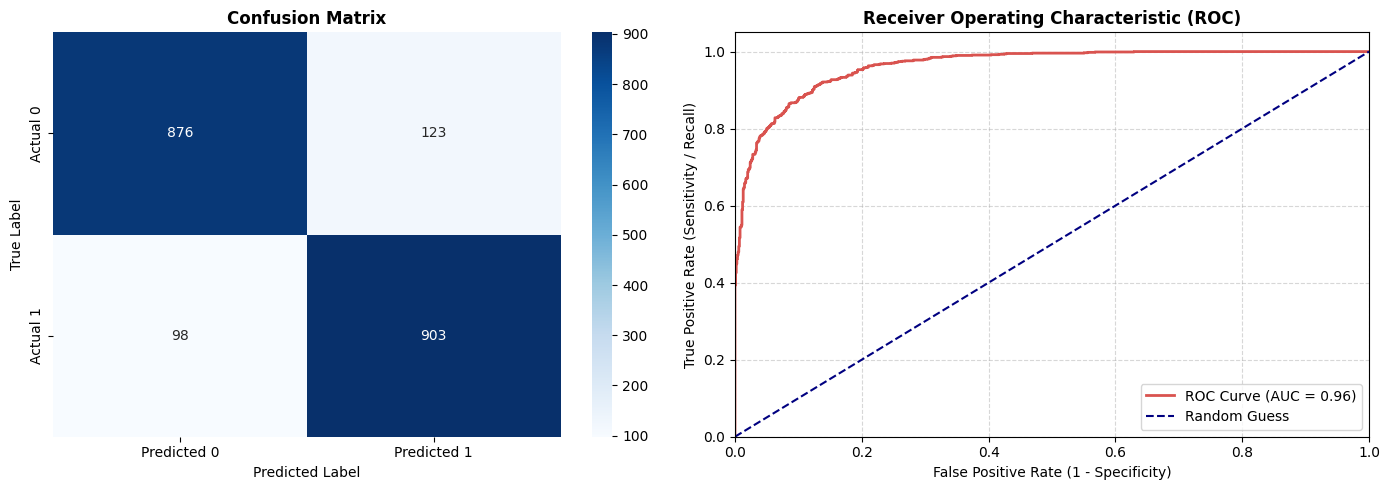


--- Model Accuracy --- for c  1000
Accuracy: 88.90%

--- Classification Report --- for c 1000
              precision    recall  f1-score   support

         Low       0.90      0.88      0.89       999
        High       0.88      0.90      0.89      1001

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

ROC-AUC Score:     0.9627


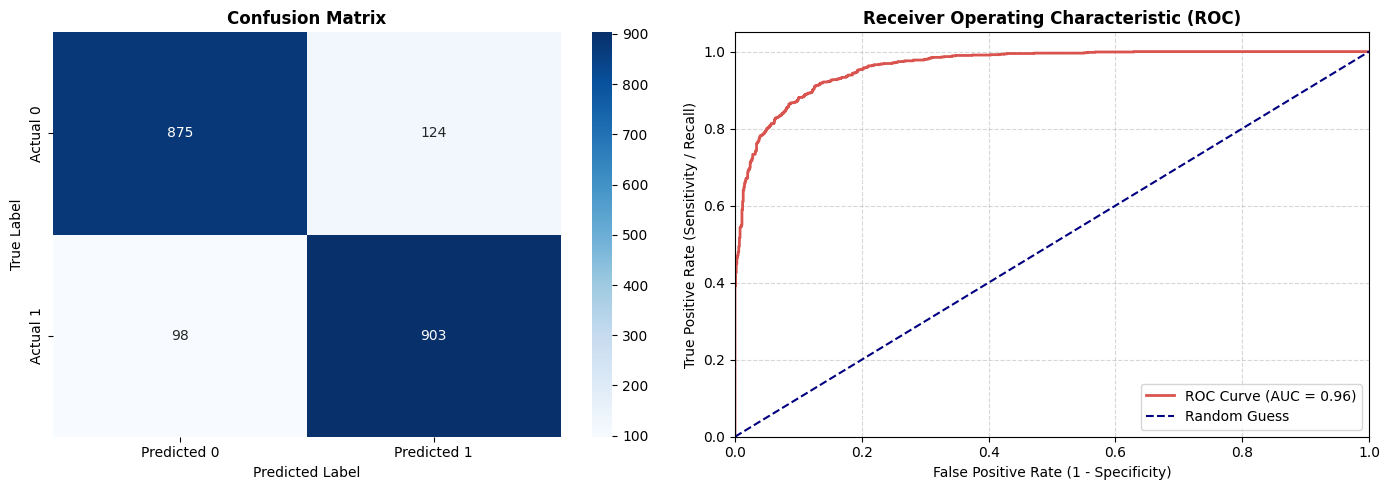

In [23]:
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    roc_curve
)

# 4. SVM Model Development
# Participants are encouraged to experiment with:
# Linear SVM 
def linear_svm(X_train, y_train, X_test, y_test, c):
    linear_svc = SVC(kernel='linear', C=c, random_state=42, probability=True)
    linear_svc.fit(X_train, y_train)
    
    # 5. Make Predictions
    y_pred = linear_svc.predict(X_test)
    
    # 6. Evaluate the Model
    print("\n--- Model Accuracy --- for c ", c)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    
    print("\n--- Classification Report --- for c", c)
    print(classification_report(y_test, y_pred, target_names=['Low', 'High']))

    # Get predicted probabilities for the positive class (1) for ROC-AUC
    y_probs = linear_svc.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_probs)
    print(f"ROC-AUC Score:     {roc_auc:.4f}")
    cm = confusion_matrix(y_test, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['Actual 0', 'Actual 1'])
    axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    axes[1].plot(fpr, tpr, color='#d9534f', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)')
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('svm_evaluation.png', dpi=300)
    plt.show()


C_values = [0.01, 0.1, 1, 10, 1000]

for i, C in enumerate(C_values):
    linear_svm(X_train, y_train, X_test, y_test, C)

    

#Tuning c - no major difference in key metrics - can choose c=0.1


 RBF SVM EVALUATION METRICS for  C  0.1  gamma  0.1
Accuracy:          0.8910
Precision:         0.8857
Recall:            0.8981
F1 Score:          0.8919
ROC-AUC Score:     0.9615



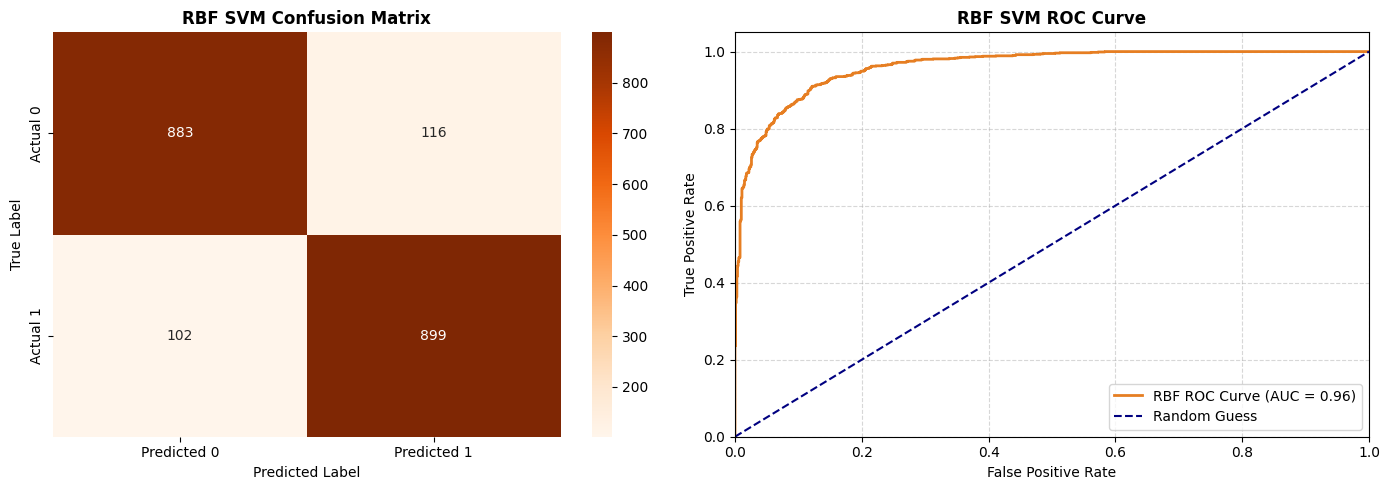

 RBF SVM EVALUATION METRICS for  C  1  gamma  0.1
Accuracy:          0.8925
Precision:         0.8838
Recall:            0.9041
F1 Score:          0.8938
ROC-AUC Score:     0.9614



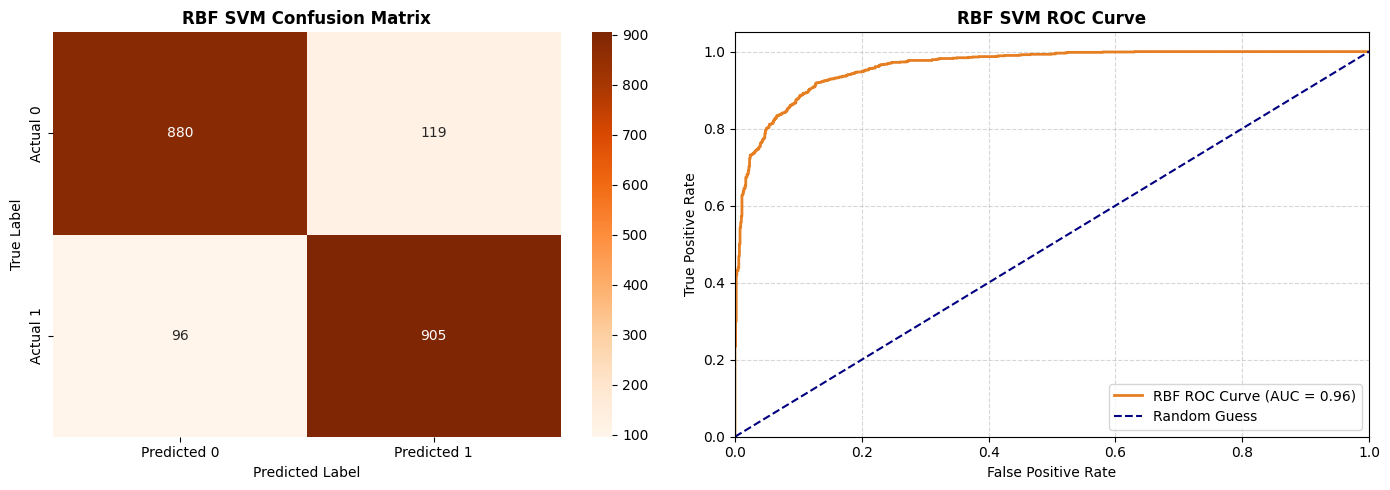

C:\Users\sramasu\Documents\Sankari\Code\18012026-20260201T073350Z-3-001\18012026\Setting up\gen-ai\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


 RBF SVM EVALUATION METRICS for  C  0.1  gamma  5
Accuracy:          0.4995
Precision:         0.0000
Recall:            0.0000
F1 Score:          0.0000
ROC-AUC Score:     0.5000



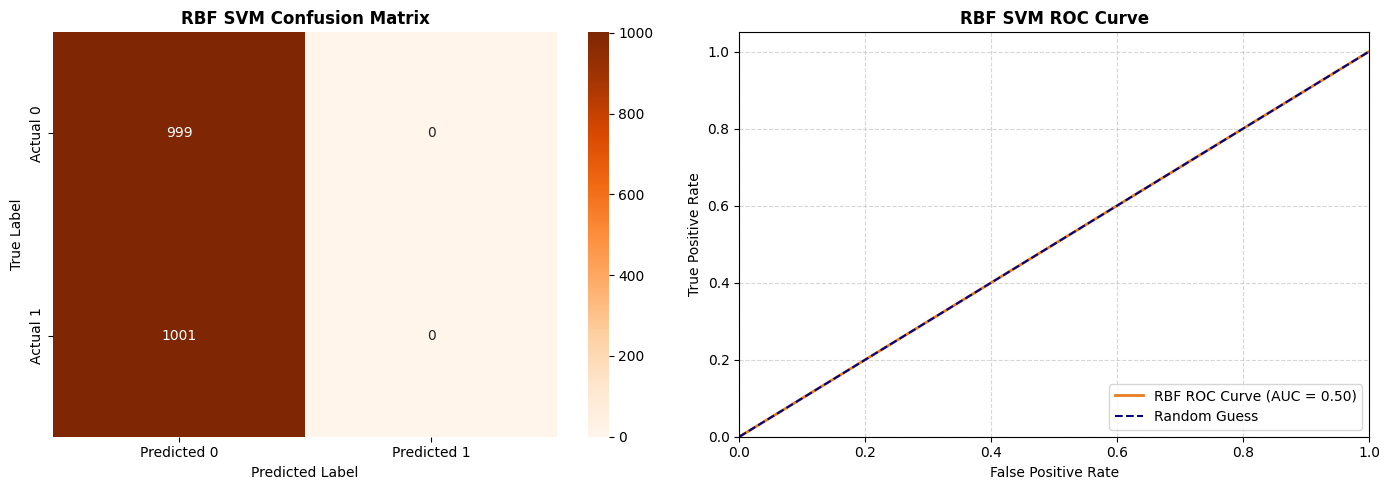

 RBF SVM EVALUATION METRICS for  C  1  gamma  5
Accuracy:          0.8505
Precision:         0.8482
Recall:            0.8541
F1 Score:          0.8512
ROC-AUC Score:     0.8805



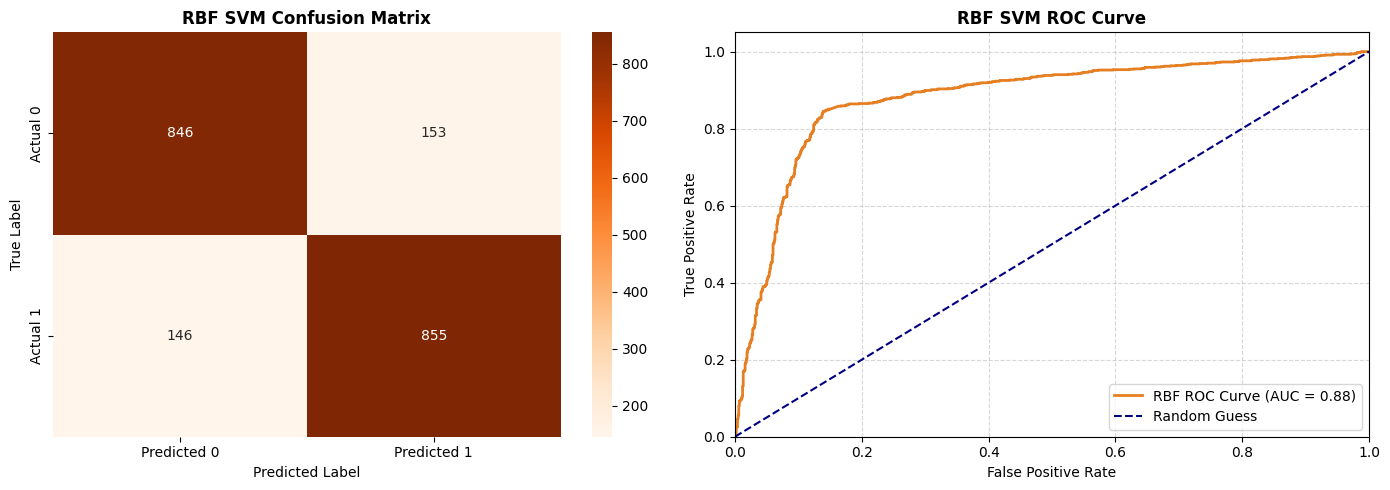

 RBF SVM EVALUATION METRICS for  C  10  gamma  0.1
Accuracy:          0.8890
Precision:         0.8793
Recall:            0.9021
F1 Score:          0.8905
ROC-AUC Score:     0.9593



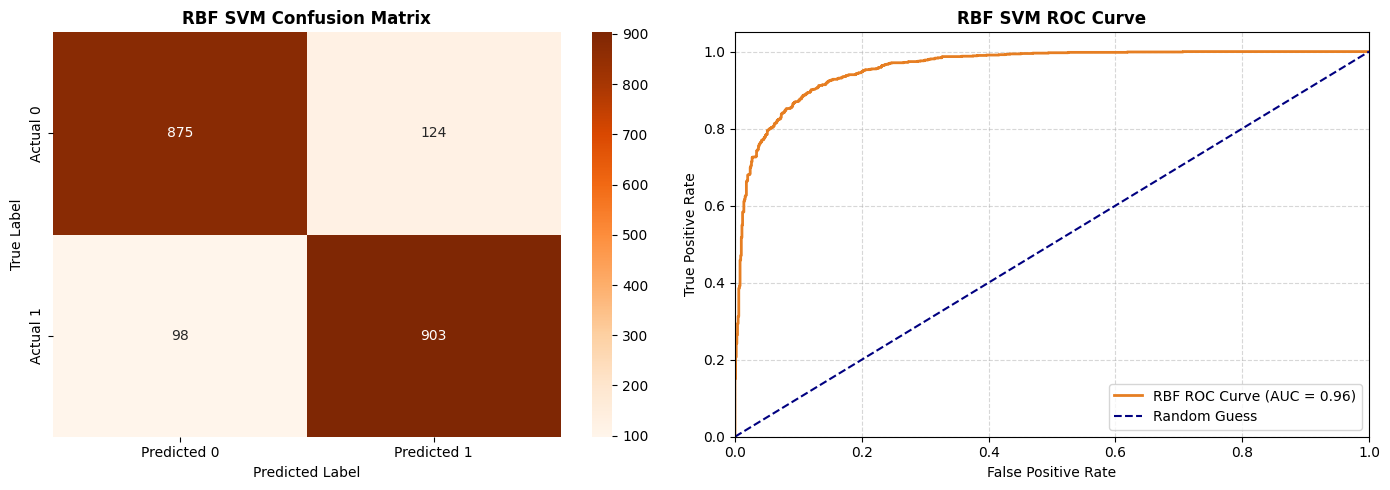

 RBF SVM EVALUATION METRICS for  C  10  gamma  5
Accuracy:          0.8505
Precision:         0.8496
Recall:            0.8521
F1 Score:          0.8509
ROC-AUC Score:     0.8794



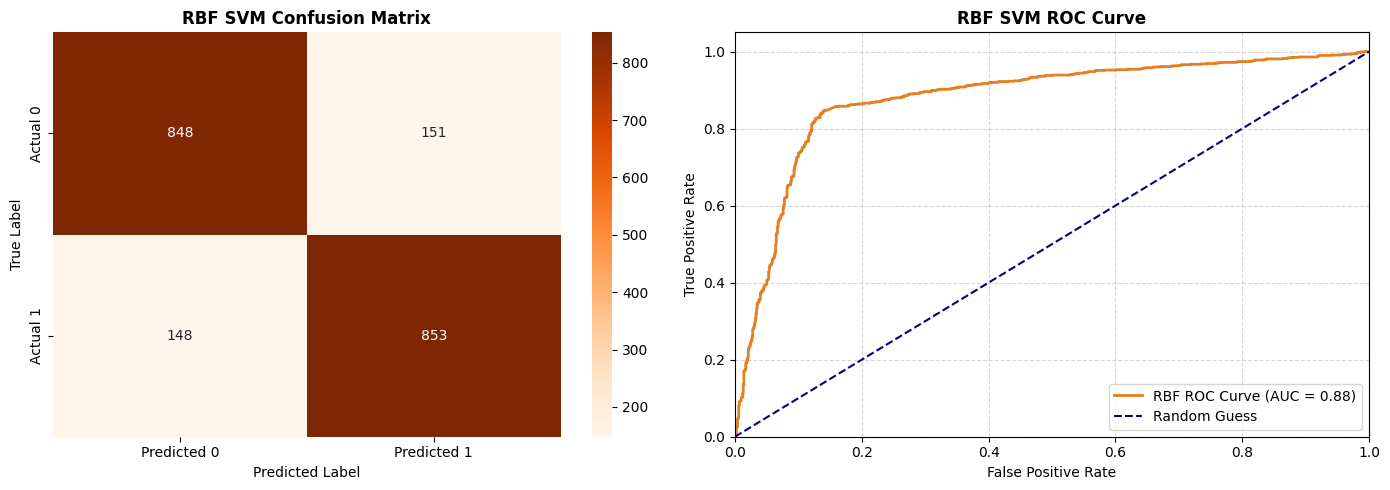

 RBF SVM EVALUATION METRICS for  C  100  gamma  0.1
Accuracy:          0.8820
Precision:         0.8768
Recall:            0.8891
F1 Score:          0.8829
ROC-AUC Score:     0.9521



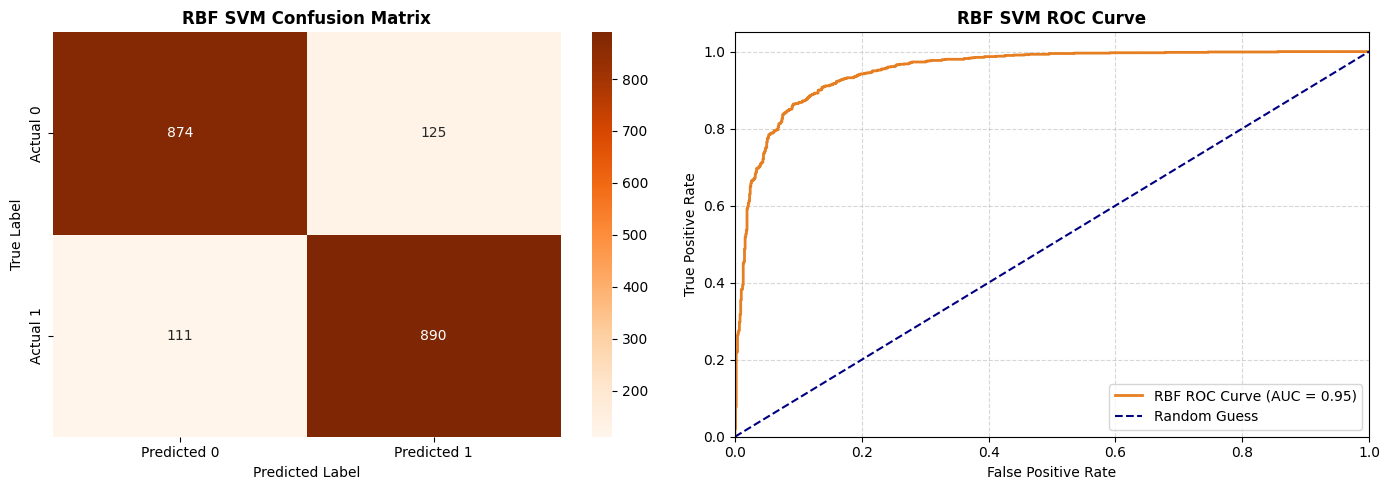

 RBF SVM EVALUATION METRICS for  C  100  gamma  5
Accuracy:          0.8505
Precision:         0.8496
Recall:            0.8521
F1 Score:          0.8509
ROC-AUC Score:     0.8794



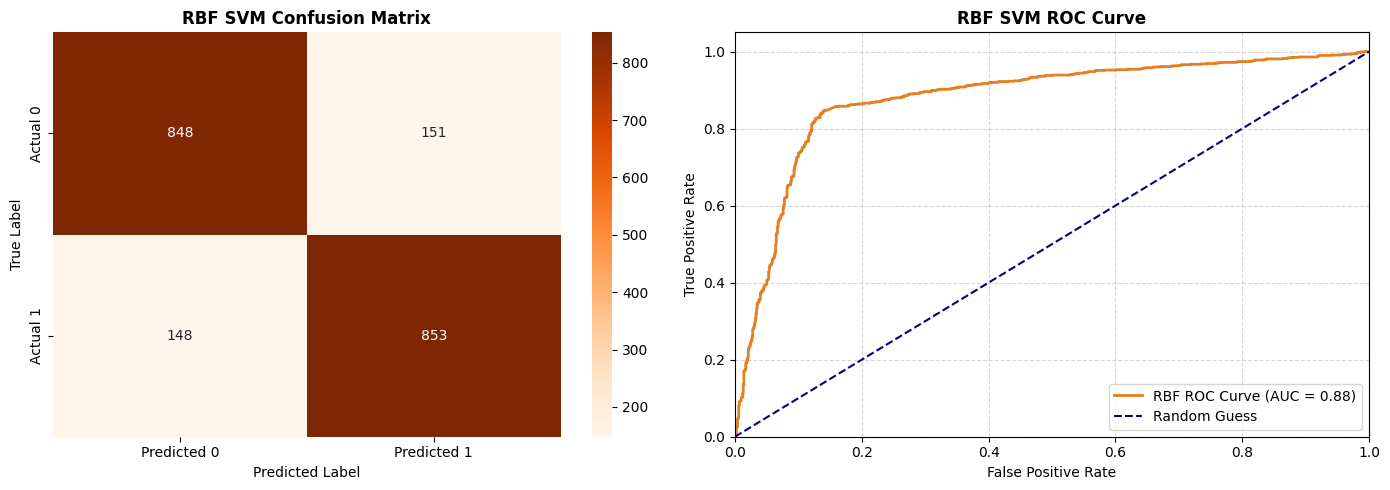

 RBF SVM EVALUATION METRICS for  C  1000  gamma  0.1
Accuracy:          0.8720
Precision:         0.8744
Recall:            0.8691
F1 Score:          0.8717
ROC-AUC Score:     0.9445



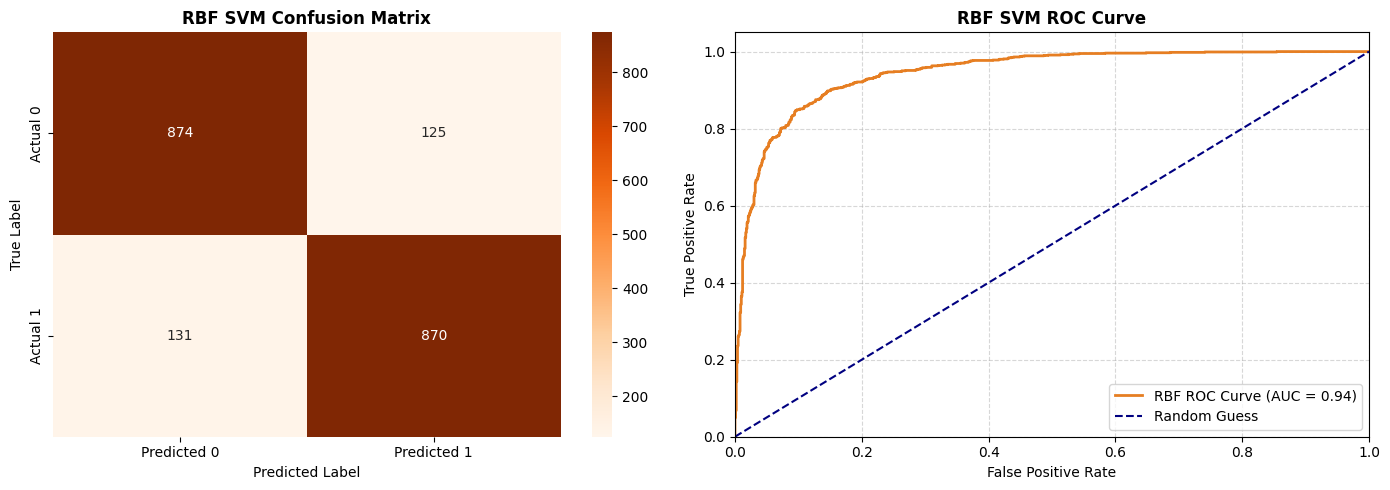

 RBF SVM EVALUATION METRICS for  C  1000  gamma  5
Accuracy:          0.8505
Precision:         0.8496
Recall:            0.8521
F1 Score:          0.8509
ROC-AUC Score:     0.8794



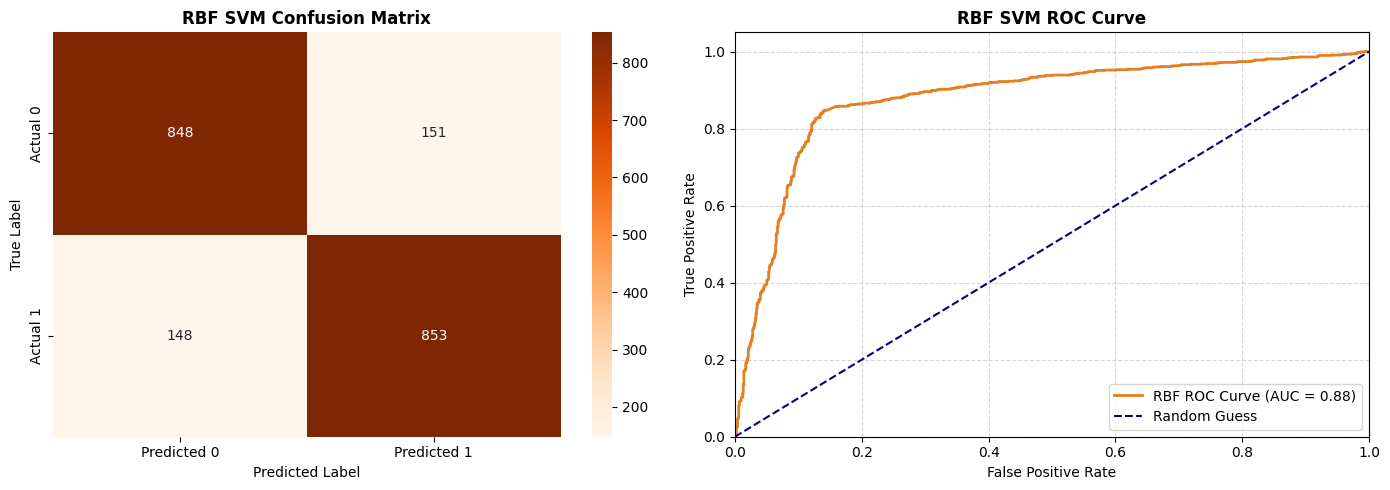

In [33]:
# RBF Kernel SVM 
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)
    
# 1. Initialize the SVC with 'rbf' kernel
# 'scale' is the default for gamma, calculating 1 / (n_features * X.var())
def rbf_svc(X_train, y_train, X_test, y_test, c, g):
    rbf_svc = SVC(kernel='rbf', C=c, gamma=g, probability=True, random_state=42)
    rbf_svc.fit(X_train, y_train)
    
    # 2. Generate Predictions and Probabilities
    y_pred_rbf = rbf_svc.predict(X_test)
    y_probs_rbf = rbf_svc.predict_proba(X_test)[:, 1]
    
    # 3. Calculate Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred_rbf)
    precision = precision_score(y_test, y_pred_rbf)
    recall = recall_score(y_test, y_pred_rbf)
    f1 = f1_score(y_test, y_pred_rbf)
    roc_auc = roc_auc_score(y_test, y_probs_rbf)
    cm = confusion_matrix(y_test, y_pred_rbf)
    
    print("=========================================")
    print(" RBF SVM EVALUATION METRICS for  C " , c, " gamma ", g)
    print("=========================================")
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"F1 Score:          {f1:.4f}")
    print(f"ROC-AUC Score:     {roc_auc:.4f}")
    print("=========================================\n")
    
    # 4. Plot Evaluation Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['Actual 0', 'Actual 1'])
    axes[0].set_title('RBF SVM Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs_rbf)
    axes[1].plot(fpr, tpr, color='#e67e22', lw=2, label=f'RBF ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('RBF SVM ROC Curve', fontsize=12, fontweight='bold')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    return rbf_svc

gamma1, gamma2 = 0.1, 5
C1, C2, C3, C4, C5 = 0.1, 1, 10, 100, 1000
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2), (gamma1, C3), (gamma2, C3), (gamma1, C4), (gamma2, C4), (gamma1, C5), (gamma2, C5)

for gamma, C in hyperparams:
    model = rbf_svc(X_train, y_train, X_test, y_test, C, gamma)

#with different C and gamma C=10  gamma  0.1 performs better as per confusion matrix and F1 score



In [35]:
from sklearn.model_selection import GridSearchCV

# hyperparam tuning with Grid search CV
param_grid = {
    'C': [1, 5, 8, 10],
    'gamma': [0.1, 1, 5, 10, 'scale']
}

# Set up Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=42), 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1', # Optimizing for a balance of precision and recall
    n_jobs=-1
)

# Run the search on your scaled training data
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")


Best parameters found: {'C': 1, 'gamma': 0.1}


In [42]:
from scipy.stats import uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV

# Polynomial Kernel SVM 
# 1. Define a broad parameter space spanning multiple kernels
# We use a list of dictionaries to ensure kernel-specific parameters are only matched together
param_distributions = [
    {
        'kernel': ['linear'],
        'C': loguniform(1e-2, 1e2)  # Continuous distribution from 0.01 to 100
    },
    {
        'kernel': ['rbf'],
        'C': loguniform(1e-2, 1e2),
        'gamma': loguniform(1e-4, 1e0)
    },
    {
        'kernel': ['poly'],
        'C': loguniform(1e-2, 1e2),
        'degree': [2, 3, 4],       # Quadratic, Cubic, or 4th-degree shapes
        'coef0': uniform(0, 10),    # Controls high-degree vs low-degree influence
        'gamma': ['scale', 'auto']
    }
]

# 2. Set up Randomized Search with 5-fold cross-validation
# n_iter=30 means it will randomly pick 30 combinations to test
random_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='f1',       # Optimizing for balanced Precision and Recall
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 3. Fit the search model
print("Starting Randomized Search across Linear, RBF, and Poly kernels...")
random_search.fit(X_train, y_train)

# 4. View the Best Results
print("\n=========================================")
print("       OPTIMAL HYPERPARAMETERS FOUND     ")
print("=========================================")
print(f"Best Kernel: {random_search.best_params_['kernel']}")
print("All Best Parameters:")
for param, val in random_search.best_params_.items():
    print(f"  - {param}: {val}")
print("=========================================\n")


best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Best Model:")
print(best_model)

print("=========================================")
print("  Randomized SearchCV EVALUATION METRICS  ")
print("=========================================")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"ROC-AUC Score:     {roc_auc:.4f}")
print("=========================================\n")

print("\nClassification Report for Best Overall Model:")
print(classification_report(y_test, y_pred, target_names=['Loe Strength', 'High Strength']))


Starting Randomized Search across Linear, RBF, and Poly kernels...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

       OPTIMAL HYPERPARAMETERS FOUND     
Best Kernel: linear
All Best Parameters:
  - C: 0.06235377135673159
  - kernel: linear

Best Model:
SVC(C=np.float64(0.06235377135673159), kernel='linear', probability=True,
    random_state=42)
  Randomized SearchCV EVALUATION METRICS  
Accuracy:          0.8895
Precision:         0.8809
Recall:            0.9011
F1 Score:          0.8909
ROC-AUC Score:     0.8895


Classification Report for Best Overall Model:
               precision    recall  f1-score   support

 Loe Strength       0.90      0.88      0.89       999
High Strength       0.88      0.90      0.89      1001

     accuracy                           0.89      2000
    macro avg       0.89      0.89      0.89      2000
 weighted avg       0.89      0.89      0.89      2000



In [50]:
# kernel performance 
# model generalization 
print(random_search.cv_results_)

{'mean_fit_time': array([1.51876838e+01, 7.68879633e+00, 7.37548776e+00, 4.40711918e+00,
       2.85409441e+01, 8.03438549e+00, 5.55725284e+00, 5.59662838e+00,
       7.86803074e+00, 8.27209397e+01, 5.04634595e+00, 7.01361837e+00,
       4.09261985e+00, 9.15762897e+02, 1.99418430e+01, 1.62085752e+01,
       2.07002525e+01, 1.38436313e+01, 2.50245689e+02, 3.94252580e+01,
       4.05872097e+00, 7.11357598e+00, 4.10317659e+00, 3.64572053e+00,
       7.27188315e+00, 4.33474565e+00, 3.74432073e+03, 7.86809702e+00,
       2.78313194e+01, 3.08376205e+01]), 'std_fit_time': array([  0.51456849,   0.74339838,   0.27069043,   0.29316102,
         0.71469538,   0.41262826,   0.4961695 ,   0.21179529,
         0.27430275,   2.83539559,   0.41260318,   0.90503265,
         0.33916211,  28.6877665 ,   0.9705009 ,   0.36777419,
         1.59225035,   0.58951748,  21.54769997,   1.11076563,
         0.46997841,   0.62555497,   0.54044388,   0.39087854,
         0.59857627,   0.50240859, 117.80242754,  

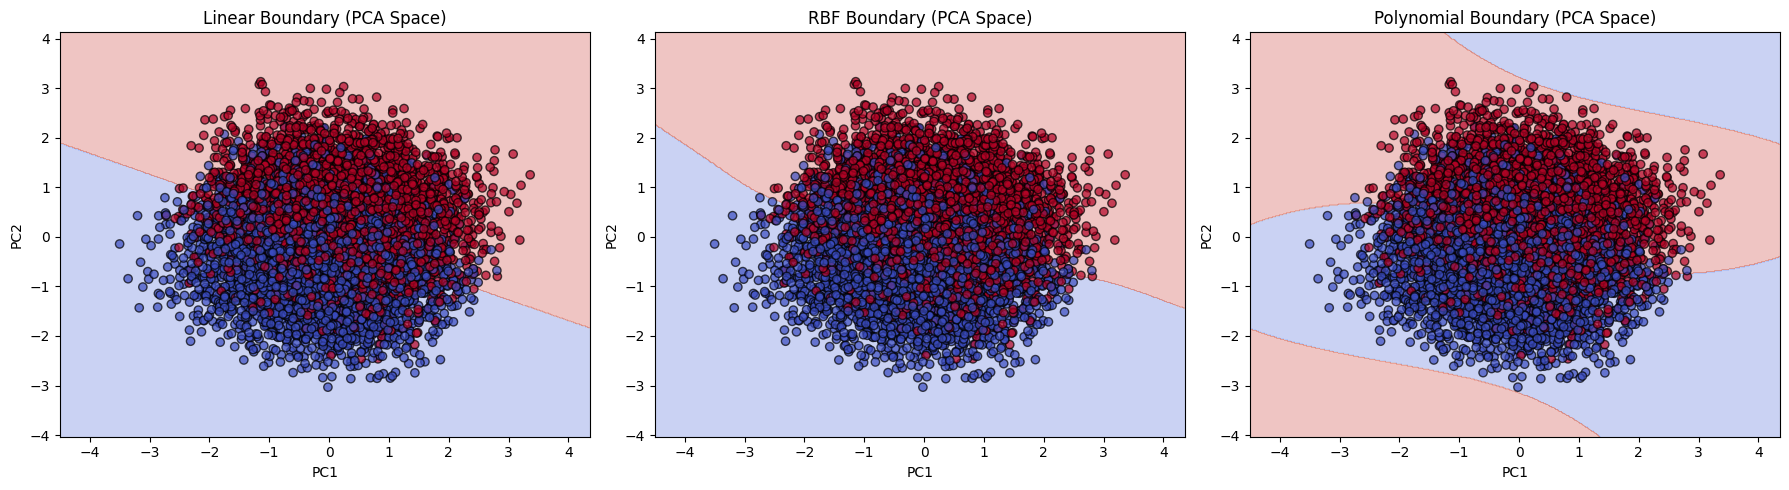

In [51]:
# For this scenario, Linear SVC has been categorized as the best model by Randomized search CV
# Params: C=np.float64(0.06235377135673159), kernel='linear', probability=True,random_state=42

# Participants may compare:
# kernel performance 
# model generalization 
# classification boundaries 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Reduce features to 2 dimensions using PCA for visualization purposes
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Helper function to plot decision boundaries
def plot_boundary(kernel_name, clf, ax):
    clf.fit(X_train_pca, y_train)
    
    # Create a grid mesh
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot contour and training points
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap='coolwarm', alpha=0.7)
    ax.set_title(f"{kernel_name} Boundary (PCA Space)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

# Set up subplot grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot boundaries for basic visual setups of each kernel style
plot_boundary("Linear", SVC(kernel='linear'), axes[0])
plot_boundary("RBF", SVC(kernel='rbf', gamma='scale'), axes[1])
plot_boundary("Polynomial", SVC(kernel='poly', degree=3, coef0=1), axes[2])

plt.tight_layout()
plt.savefig('kernel_boundaries.png', dpi=300)
plt.show()
# computational efficiency 

# Hyperparameter Tuning - done
# Participants are encouraged to tune:
# C parameter 
# gamma 
# kernel type 
# using approaches such as:
# GridSearchCV 
# RandomizedSearchCV 

# Model Evaluation - done
# Participants may evaluate models using:
# Accuracy 
# Precision 
# Recall 
# F1 Score 
# ROC-AUC Score 
# Confusion Matrix 